# Dynex SDK - Simple Shor Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from fractions import Fraction
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit "Shor for Integer Factorization":

In [2]:
# to draw the circuit we can assume N = 35 and a = 12
a = 12
N = 35
params = [N, a]
wires = 10 + int(np.ceil(np.log2(N)))  # 10 estimated qubits for computing the period (r) 


def _GetU_NA(a, N):
    nQ = int(np.ceil(np.log2(N)))
    uNA = np.zeros([2 ** nQ, 2 ** nQ])
    for k in range(N):
        uNA[(k * a) % N, k] = 1
    for extra in range(N, 2 ** nQ):
        uNA[extra, extra] = 1
    return uNA


def ShorsCircuit(params):
    N, a = int(params[0]), int(params[1])
    uNA = _GetU_NA(a, N)
    nEstimateQUBITS = 10
    nTargetQUBITS = int(np.ceil(np.log2(N)))
    tQ = nEstimateQUBITS + nTargetQUBITS
    estWIRES = range(nEstimateQUBITS)
    tWAIRES = range(nEstimateQUBITS, tQ)
    qml.PauliX(wires=tWAIRES[-1])
    for wire in estWIRES:
        qml.Hadamard(wires=wire)
    for i, wire in enumerate(estWIRES):
        power = 2 ** (nEstimateQUBITS - i - 1)
        qml.ctrl(qml.QubitUnitary(qml.math.linalg.matrix_power(uNA, power), wires=list(tWAIRES)), control=[wire])
    qml.adjoint(qml.QFT)(wires=estWIRES)
    return qml.sample()


def Fraction2Float(sample):
    return np.sum([int(sample[bit]) / 2 ** (bit + 1) for bit in range(len(sample))])


def Phase2Order(phase, max_denominator):
    sR = Fraction(phase)
    order = sR.limit_denominator(max_denominator).denominator
    if order % 2 == 0:
        return order
    else:
        return order + 1  # get only even Period (correction)

We draw the circuit:

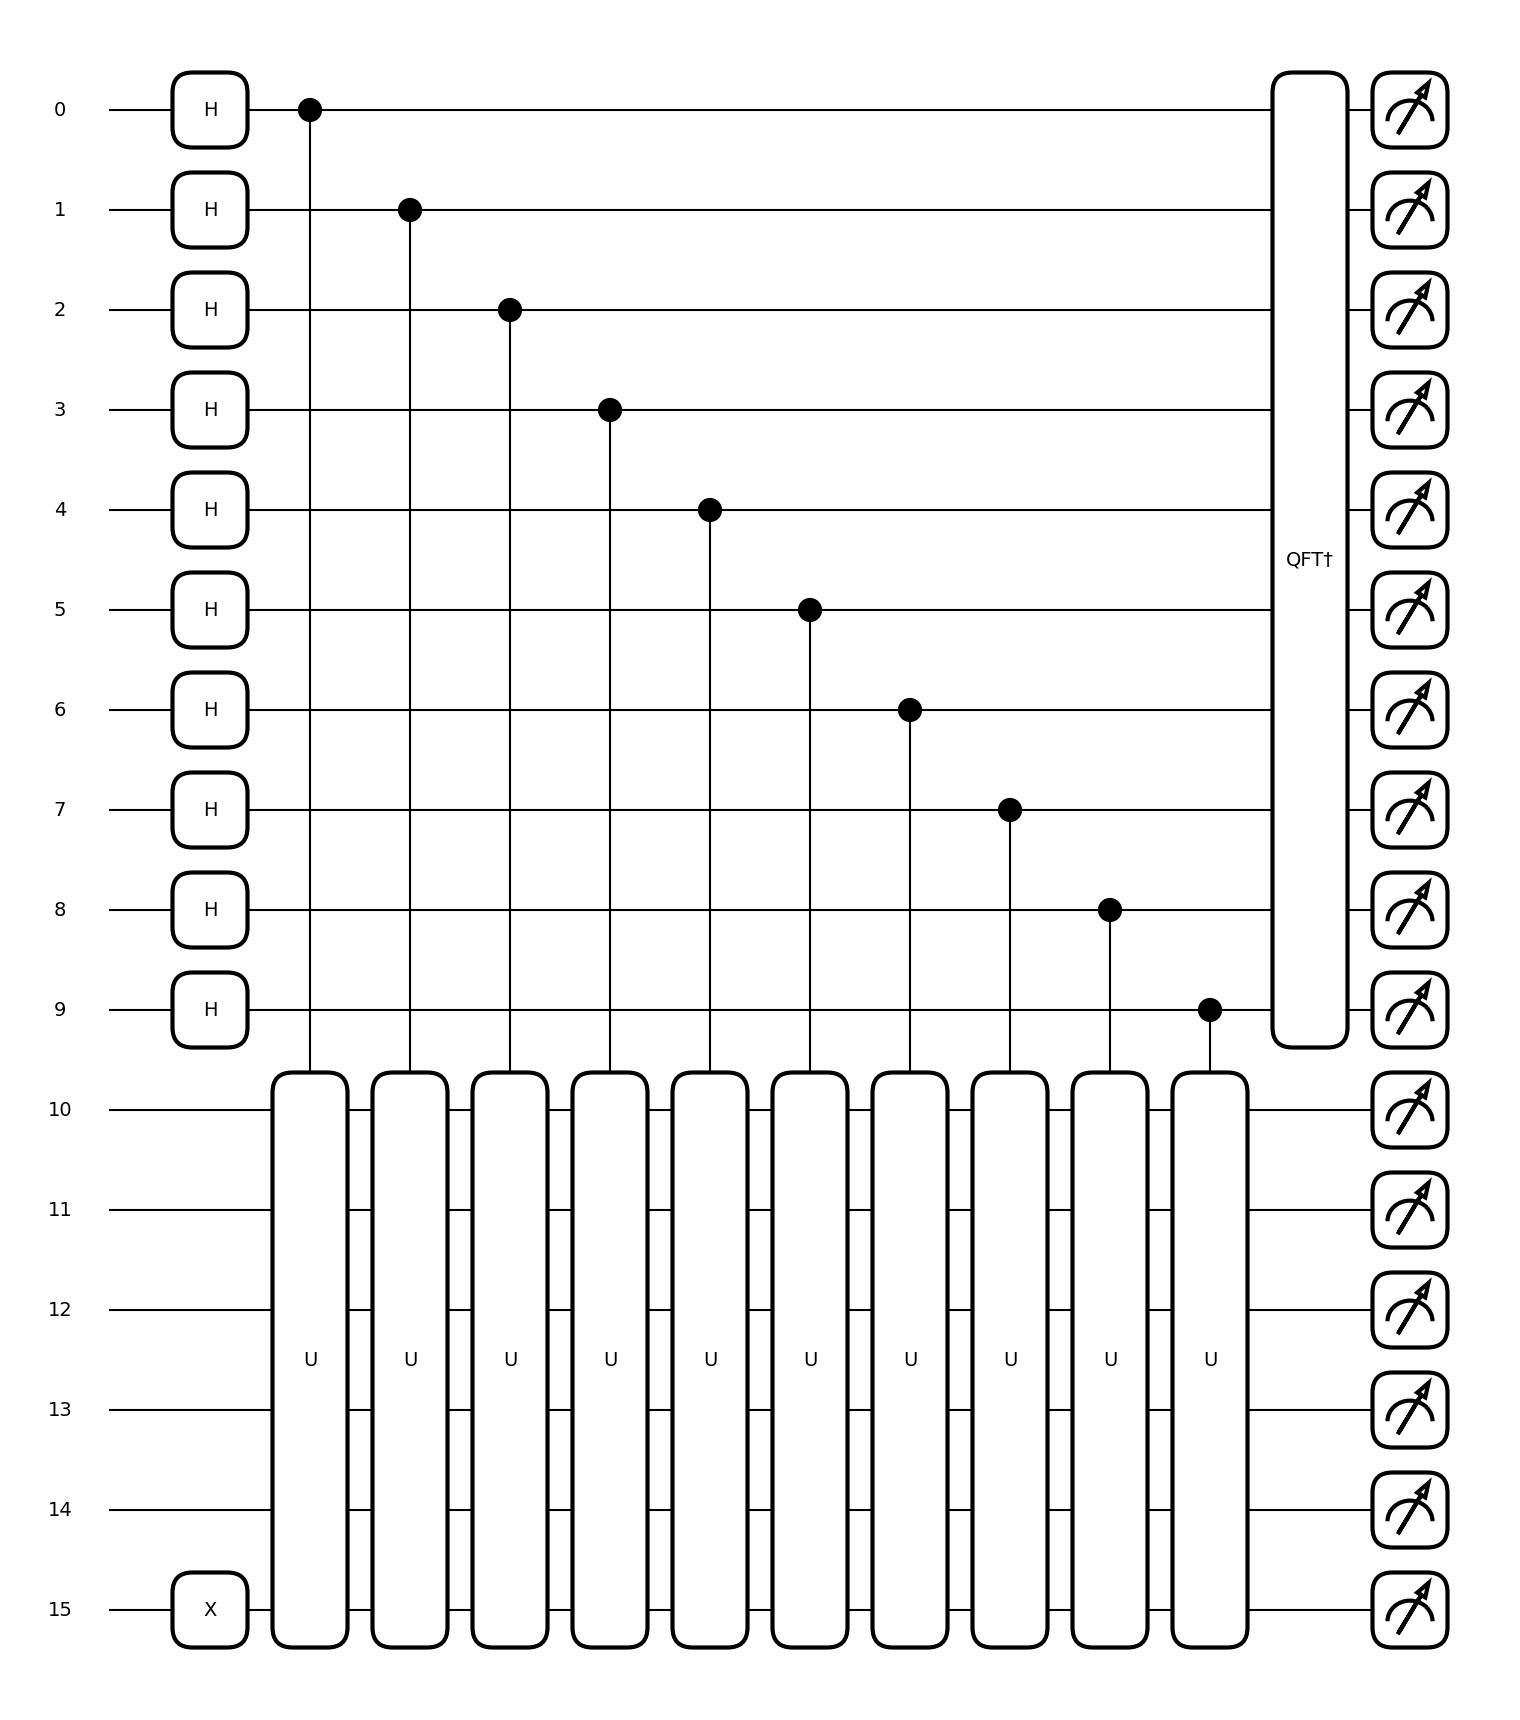

In [3]:
# draw circuit:
_ = qml.draw_mpl(ShorsCircuit, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
def SimpleShorsAlgo(N):
    max_its = 10
    for _ in range(max_its):
        a = np.random.choice(list(range(2, N - 1)))
        print(f"Chose a={a}")
        params = [N, a]
        wires = 10 + int(np.ceil(np.log2(N)))
        dynex_circuit = DynexCircuit(config=config)
        solutions = dynex_circuit.execute(ShorsCircuit, params, wires, method="all", num_reads=1,
                                          integration_steps=100)
        for solution in solutions:
            solution_array = np.array(solution)
            estimated_bits = solution_array[-10:]  # Take the estimated qubits ONLY `nEstimateQUBITS`
            phase = Fraction2Float(estimated_bits)
            r = Phase2Order(phase, N)
            x = a ** (r // 2) % N
            if x == 1 or x == N - 1:
                continue
            p = np.gcd(x - 1, N)
            q = np.gcd(x + 1, N)
            if p * q == N:
                print(f"Found solution:")
                print(f"r = {r}, x = {x}")
                print(f"p = {p}, q = {q}")
                return p, q
    print("No solution found after maximum iterations. (We need to find proper way for the `a`)")
    return None, None


N = 35
p, q = SimpleShorsAlgo(N)
print(f"Factorization of {N}: {p} and {q}")

Chose a=11


INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=1, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7421)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'U_0_0_imag': 0, 'U_0_0_real': 1, 'U_0_10_imag': 0, 'U_0_10_real': 0, 'U_0_11_imag': 0, 'U_0_11_real': 0, 'U_0_12_imag': 0, 'U_0_12_real': 0, 'U_0_13_imag': 0, 'U_0_13_real': 0, 'U_0_14_imag': 0, 'U_0_14_real': 0, 'U_0_15_imag': 0, 'U_0_15_real': 0, 'U_0_16_imag': 0, 'U_0_16_real': 0, 'U_0_17_imag': 0, 'U_0_17_real': 0, 'U_0_18_imag': 0, 'U_0_18_real': 0, 'U_0_19_imag': 0, 'U_0_19_real': 0, 'U_0_1_imag': 0, 'U_0_1_real': 0, 'U_0_20_imag': 0, 'U_0_20_real': 0, 'U_0_21_imag': 0, 'U_0_21_real': 0, 'U_0_22_imag': 0, 'U_0_22_real': 0, 'U_0_23_imag': 0, 'U_0_23_real': 0, 'U_0_24_imag': 0, 'U_0_24_rea

Chose a=29


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7422)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'U_0_0_imag': 0, 'U_0_0_real': 1, 'U_0_10_imag': 0, 'U_0_10_real': 0, 'U_0_11_imag': 0, 'U_0_11_real': 0, 'U_0_12_imag': 0, 'U_0_12_real': 0, 'U_0_13_imag': 0, 'U_0_13_real': 0, 'U_0_14_imag': 0, 'U_0_14_real': 0, 'U_0_15_imag': 0, 'U_0_15_real': 0, 'U_0_16_imag': 0, 'U_0_16_real': 0, 'U_0_17_imag': 0, 'U_0_17_real': 0, 'U_0_18_imag': 0, 'U_0_18_real': 0, 'U_0_19_imag': 0, 'U_0_19_real': 0, 'U_0_1_imag': 0, 'U_0_1_real': 0, 'U_0_20_imag': 0, 'U_0_20_real': 0, 'U_0_21_imag': 0, 'U_0_21_real': 0, 'U_0_22_imag': 0, 'U_0_22_real': 0, 'U_0_23_imag': 0, 'U_0_23_real': 0, 'U_0_24_imag': 0, 'U_0_24_real': 0, 'U_0_25_imag': 0, 'U_0_25_real': 0, 'U_0_26_imag': 0, 'U_0_26_real': 0, 'U_0_27_imag': 0, 'U_0_27_real': 0, 'U_0_28_imag': 0, 'U_0_28_real': 0, 'U_0_29_imag': 0, 'U_0_29_real': 0, 'U_0_2_imag': 0, 'U_0_2_real': 0, 'U_0_30_imag': 0, 'U_0_30_real': 0, 'U_0_31_imag': 0, 'U_0_31_real':

Chose a=3


...

Chose a=5


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7429)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'U_0_0_imag': 0, 'U_0_0_real': 1, 'U_0_10_imag': 0, 'U_0_10_real': 0, 'U_0_11_imag': 0, 'U_0_11_real': 0, 'U_0_12_imag': 0, 'U_0_12_real': 0, 'U_0_13_imag': 0, 'U_0_13_real': 0, 'U_0_14_imag': 0, 'U_0_14_real': 1, 'U_0_15_imag': 0, 'U_0_15_real': 0, 'U_0_16_imag': 0, 'U_0_16_real': 0, 'U_0_17_imag': 0, 'U_0_17_real': 0, 'U_0_18_imag': 0, 'U_0_18_real': 0, 'U_0_19_imag': 0, 'U_0_19_real': 0, 'U_0_1_imag': 0, 'U_0_1_real': 0, 'U_0_20_imag': 0, 'U_0_20_real': 0, 'U_0_21_imag': 0, 'U_0_21_real': 1, 'U_0_22_imag': 0, 'U_0_22_real': 0, 'U_0_23_imag': 0, 'U_0_23_real': 0, 'U_0_24_imag': 0, 'U_0_24_real': 0, 'U_0_25_imag': 0, 'U_0_25_real': 0, 'U_0_26_imag': 0, 'U_0_26_real': 0, 'U_0_27_imag': 0, 'U_0_27_real': 0, 'U_0_28_imag': 0, 'U_0_28_real': 1, 'U_0_29_imag': 0, 'U_0_29_real': 0, 'U_0_2_imag': 0, 'U_0_2_real': 0, 'U_0_30_imag': 0, 'U_0_30_real': 0, 'U_0_31_imag': 0, 'U_0_31_real':

Chose a=23


INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7430)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'U_0_0_imag': 0, 'U_0_0_real': 1, 'U_0_10_imag': 0, 'U_0_10_real': 0, 'U_0_11_imag': 0, 'U_0_11_real': 0, 'U_0_12_imag': 0, 'U_0_12_real': 0, 'U_0_13_imag': 0, 'U_0_13_real': 0, 'U_0_14_imag': 0, 'U_0_14_real': 0, 'U_0_15_imag': 0, 'U_0_15_real': 0, 'U_0_16_imag': 0, 'U_0_16_real': 0, 'U_0_17_imag': 0, 'U_0_17_real': 0, 'U_0_18_imag': 0, 'U_0_18_real': 0, 'U_0_19_imag': 0, 'U_0_19_real': 0, 'U_0_1_imag': 0, 'U_0_1_real': 0, 'U_0_20_imag': 0, 'U_0_20_real': 0, 'U_0_21_imag': 0, 'U_0_21_real': 0, 'U_0_22_imag': 0, 'U_0_22_real': 0, 'U_0_23_imag': 0, 'U_0_23_real': 0, 'U_0_24_imag': 0, 'U_0_24_real': 0, 'U_0_25_imag': 0, 'U_0_25_real': 0, 'U_0_26_imag': 0, 'U_0_26_real': 0, 'U_0_27_imag': 0, 'U_0_27_real': 0, 'U_0_28_imag': 0, 'U_0_28_real': 0, 'U_0_29_imag': 0, 'U_0_29_real': 0, 'U_0_2_imag': 0, 'U_0_2_real': 0, 'U_0_30_imag': 0, 'U_0_30_real': 0, 'U_0_31_imag': 0, 'U_0_31_real':

No solution found after maximum iterations. (We need to find proper way for the `a`)
Factorization of 35: None and None
